In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

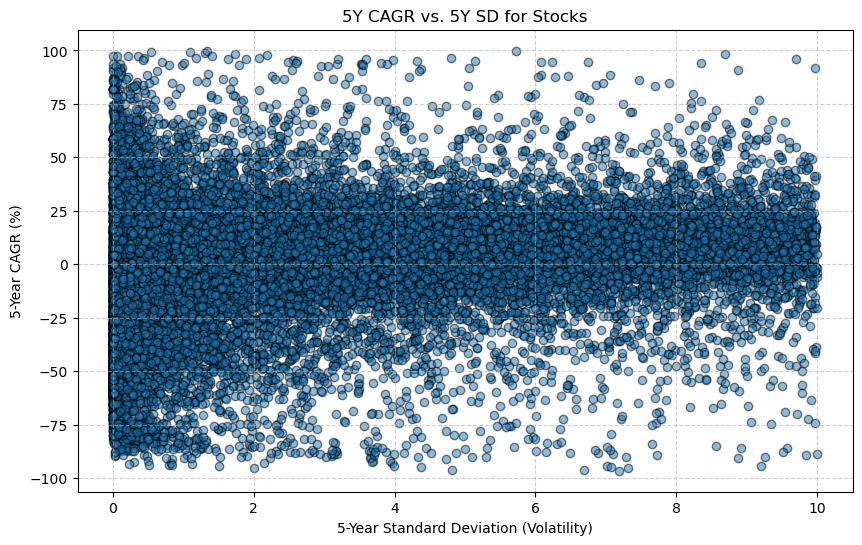

In [4]:
file_path = r"C:\Users\thoma\Desktop\Projects\Untitled Folder\all_stocks_sd_cagr.csv"  # Adjust if the file is in a different location
df = pd.read_csv(file_path)

# Drop rows with NaN values in '5Y SD' or '5Y CAGR'
df = df.dropna(subset=["5Y SD", "5Y CAGR"])

# Convert to numeric and filter out invalid values
df["5Y SD"] = pd.to_numeric(df["5Y SD"], errors="coerce")
df["5Y CAGR"] = pd.to_numeric(df["5Y CAGR"], errors="coerce")

# Remove zero values (prevents division errors and meaningless data points)
df = df[(df["5Y SD"] > 0) & (df["5Y CAGR"] > -100)]  # CAGR > -100% avoids nonsense values

# Remove extreme outliers (e.g., incorrectly parsed numbers)
df = df[(df["5Y SD"] < 10) & (df["5Y CAGR"] < 100)]  # Adjust if needed

# Extract values
x = df["5Y SD"]
y = df["5Y CAGR"]

# Create scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(x, y, alpha=0.5, edgecolors="k")

# Labels and title
plt.xlabel("5-Year Standard Deviation (Volatility)")
plt.ylabel("5-Year CAGR (%)")
plt.title("5Y CAGR vs. 5Y SD for Stocks")

# Grid and show plot
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()